![Databricks Academy](https://files.training.databricks.com/binder/prod_main/automated-deployment-with-declarative-automation-bundles-en_us-2.4.0/images/20260828T161450Z/Automated Deployment with Declarative Automation Bundles/Includes/images/common/db-academy.png)

# Lecture - CI/CD Project Overview with DABs

## Overview

In this lecture, you will look at the end-to-end project used for the rest of the course: what it delivers, its architecture across dev, stage, and production, the testing strategy (unit, integration, and system tests), and how CI/CD fits together with Declarative Automation Bundles.

## Learning Objectives

By the end of this lecture, you will be able to:
1. **Describe** the course project's requirements and architecture.
2. **Explain** the role of unit, integration, and system tests in CI/CD.
3. **Review** unit testing with pytest and pipeline expectations for integration tests.
4. **Describe** how CI/CD works with DABs across development, stage, and production.

## A. Planning the Project

### A1. Requirements

<div style="display:grid;grid-template-columns:minmax(0,1.3fr) minmax(240px,0.7fr);gap:30px;max-width:1150px;margin:0 auto;font-family:sans-serif;align-items:start;">
  <div>
    <div style="font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:6px;">Deliverable</div>
    <ul style="font-size:14pt;color:#0b2026;padding-left:20px;margin:0 0 18px 0;"><li>Visualize Health Data</li></ul>
    <div style="font-size:16pt;font-weight:700;color:#0b2026;margin-bottom:6px;">Tasks</div>
    <ul style="font-size:14pt;color:#0b2026;padding-left:20px;margin:0;line-height:1.5;">
      <li>Ingest daily incremental CSV files to a bronze table</li>
      <li>Create a clean silver table</li>
      <li>Create gold tables to share with consumers</li>
    </ul>
  </div>
  <div>
    <div style="font-size:15pt;font-weight:700;color:#0b2026;text-align:center;margin-bottom:12px;">Databricks Assets</div>
    <div style="border:2px dashed #8A9BA8;border-radius:10px;padding:16px 18px;">
      <div style="display:flex;align-items:center;gap:10px;justify-content:center;font-size:15pt;font-weight:600;color:#0b2026;margin-bottom:14px;">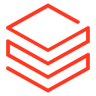 Workspace</div>
      <div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:9px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Notebooks</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:9px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">SDP</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:9px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Workflows</div><div style="background:#F6A192;color:#0b2026;font-weight:700;text-align:center;padding:9px;border-radius:5px;margin-bottom:8px;font-size:13.5pt;">Compute</div>
      <div style="text-align:center;margin-top:6px;">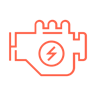</div>
    </div>
  </div>
</div>

##### Additional notes

<details>

- The project deliverable is to visualize health data.
- The tasks: ingest daily incremental CSV files to a bronze table, create a clean silver table, and create gold tables to share with consumers.
- The Databricks assets involved include a workspace with notebooks, Spark Declarative Pipelines (SDP), workflows, and compute.

</details>

### A2. Course Project Architecture

Three **catalogs** (dev, stage, prod) feed a **Lakeflow Job**: unit tests run first, then a Spark Declarative Pipeline using expectations transforms the data, producing the **Data Visualization** deliverable.

<div style="text-align:center;"><svg viewBox="0 0 1120 470" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;max-width:1120px;font-family:Helvetica,Arial,sans-serif;">
  <defs><marker id="ah" markerWidth="9" markerHeight="9" refX="6" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L6,3 L0,6 Z" fill="#FF5F46"/></marker>
        <marker id="ahk" markerWidth="9" markerHeight="9" refX="6" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L6,3 L0,6 Z" fill="#1B3139"/></marker></defs>
  <rect x="4" y="30" width="1112" height="420" rx="10" fill="none" stroke="#8A9BA8" stroke-width="1.5" stroke-dasharray="5 4"/>
  <image href="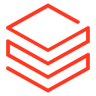" x="1050" y="44" width="40" height="40"/>
  <text x="150" y="70" font-family="Helvetica,Arial,sans-serif" font-size="17" font-weight="700" fill="#0b2026" text-anchor="middle">Catalogs</text>
  <!-- catalog boxes -->
  <rect x="30" y="88" width="240" height="60" rx="4" fill="#fff" stroke="#FF5F46" stroke-width="1.5"/><image href="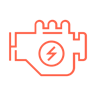" x="42" y="100" width="34" height="34"/><text x="150" y="126" font-family="Helvetica,Arial,sans-serif" font-size="17" font-weight="700" fill="#0b2026" text-anchor="middle">Dev</text>
  <text x="30" y="172" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5E7077" text-anchor="start">Small subset of prod</text>
  <rect x="30" y="196" width="240" height="60" rx="4" fill="#fff" stroke="#FF5F46" stroke-width="1.5"/><image href="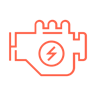" x="42" y="208" width="34" height="34"/><text x="150" y="234" font-family="Helvetica,Arial,sans-serif" font-size="17" font-weight="700" fill="#0b2026" text-anchor="middle">Stage</text>
  <text x="30" y="280" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5E7077" text-anchor="start">Larger subset of prod</text>
  <rect x="30" y="304" width="240" height="60" rx="4" fill="#fff" stroke="#FF5F46" stroke-width="1.5"/><image href="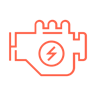" x="42" y="316" width="34" height="34"/><text x="150" y="342" font-family="Helvetica,Arial,sans-serif" font-size="17" font-weight="700" fill="#0b2026" text-anchor="middle">Prod</text>
  <text x="30" y="388" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5E7077" text-anchor="start">Daily CSV files</text>
  <!-- arrows to unit tests -->
  <path d="M270,118 L310,118 L310,210 L350,210" stroke="#FF5F46" stroke-width="2" fill="none" marker-end="url(#ah)"/>
  <path d="M270,226 L350,226" stroke="#FF5F46" stroke-width="2" fill="none" marker-end="url(#ah)"/>
  <path d="M270,334 L310,334 L310,242 L350,242" stroke="#FF5F46" stroke-width="2" fill="none" marker-end="url(#ah)"/>
  <!-- Lakeflow Job box -->
  <rect x="345" y="90" width="740" height="300" rx="6" fill="#ECEBE8" stroke="#1B3139" stroke-width="1.5" stroke-dasharray="5 4"/>
  <text x="715" y="120" font-family="Helvetica,Arial,sans-serif" font-size="17" font-weight="700" fill="#0b2026" text-anchor="middle">Lakeflow Job</text>
  <!-- Unit tests -->
  <rect x="355" y="185" width="110" height="90" rx="4" fill="#fff" stroke="#5E7077" stroke-width="1.5" stroke-dasharray="3 3"/><text x="410" y="222" font-family="Helvetica,Arial,sans-serif" font-size="14" fill="#0b2026" text-anchor="middle">Unit</text><text x="410" y="240" font-family="Helvetica,Arial,sans-serif" font-size="14" fill="#0b2026" text-anchor="middle">Tests</text>
  <path d="M465,230 L505,230" stroke="#FF5F46" stroke-width="2" fill="none" marker-end="url(#ah)"/>
  <!-- SDP box -->
  <rect x="505" y="160" width="290" height="140" rx="4" fill="#F6A192"/><text x="650" y="205" font-family="Helvetica,Arial,sans-serif" font-size="15" font-weight="700" fill="#0b2026" text-anchor="middle">Spark Declarative</text><text x="650" y="231" font-family="Helvetica,Arial,sans-serif" font-size="15" font-weight="700" fill="#0b2026" text-anchor="middle">Pipeline using</text><text x="650" y="257" font-family="Helvetica,Arial,sans-serif" font-size="15" font-weight="700" fill="#0b2026" text-anchor="middle">Expectations</text>
  <image href="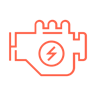" x="632" y="255" width="36" height="36"/>
  <path d="M795,230 L835,230" stroke="#FF5F46" stroke-width="2" fill="none" marker-end="url(#ah)"/>
  <!-- Deliverable -->
  <text x="940" y="150" font-family="Helvetica,Arial,sans-serif" font-size="12" fill="#5E7077" text-anchor="middle">Deliverable</text>
  <rect x="835" y="160" width="210" height="110" rx="4" fill="#F6A192"/><text x="940" y="215" font-family="Helvetica,Arial,sans-serif" font-size="16" font-weight="700" fill="#0b2026" text-anchor="middle">Data</text><text x="940" y="239" font-family="Helvetica,Arial,sans-serif" font-size="16" font-weight="700" fill="#0b2026" text-anchor="middle">Visualization</text>
  <image href="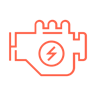" x="922" y="268" width="36" height="36"/>
</svg></div>

##### Additional notes

<details>

- Three catalogs hold the data at different scales: dev (a small subset of prod), stage (a larger subset of prod), and prod (the daily CSV files).
- Within the Lakeflow Job, unit tests run first, then a Spark Declarative Pipeline using expectations transforms the data.
- The final deliverable is the data visualization built on the pipeline's output.

</details>

## B. Testing Strategy

### B1. Review the Role of CI/CD Testing

The testing pyramid runs from many **fast** unit tests at the base up to fewer **slow** system tests at the top.

<div style="display:grid;grid-template-columns:minmax(0,0.9fr) minmax(0,1.1fr);gap:24px;max-width:1150px;margin:0 auto;font-family:sans-serif;align-items:center;">
  <div style="text-align:center;"><svg viewBox="0 0 380 320" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;max-width:380px;font-family:Helvetica,Arial,sans-serif;">
    <defs><marker id="pah" markerWidth="8" markerHeight="8" refX="4" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 Z" fill="#9AA7AE"/></marker>
          <marker id="pahs" markerWidth="8" markerHeight="8" refX="4" refY="3" orient="auto"><path d="M6,0 L0,3 L6,6 Z" fill="#9AA7AE"/></marker></defs>
    <polygon points="190,20 360,300 20,300" fill="#3B82C4"/>
    <line x1="105" y1="205" x2="275" y2="205" stroke="#fff" stroke-width="2"/>
    <line x1="148" y1="130" x2="232" y2="130" stroke="#fff" stroke-width="2"/>
    <text x="190" y="120" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#fff" text-anchor="middle">System Tests</text><text x="190" y="137" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#fff" text-anchor="middle"></text>
    <text x="190" y="178" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#fff" text-anchor="middle">Integration</text><text x="190" y="195" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#fff" text-anchor="middle">Tests</text>
    <text x="190" y="265" font-family="Helvetica,Arial,sans-serif" font-size="13" font-weight="700" fill="#fff" text-anchor="middle">Unit Tests</text>
    <line x1="8" y1="40" x2="8" y2="300" stroke="#9AA7AE" stroke-width="2" marker-start="url(#pahs)" marker-end="url(#pah)"/>
    <text x="2" y="32" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#0b2026" text-anchor="start">Slow</text>
    <text x="2" y="300" font-family="Helvetica,Arial,sans-serif" font-size="12" font-weight="700" fill="#0b2026" text-anchor="start">Fast</text>
  </svg></div>
  <div style="display:flex;flex-direction:column;gap:12px;">
    <div style="border:1px solid #3B82C4;border-radius:6px;padding:12px 16px;font-size:13pt;color:#0b2026;"><b>System Tests</b> &mdash; Test the entire application, ensuring that all parts function together in a real-world scenario. <br><b>Ex:</b> End to end data pipeline in a Workflow.</div>
    <div style="border:1px solid #3B82C4;border-radius:6px;padding:12px 16px;font-size:13pt;color:#0b2026;"><b>Integration Tests</b> &mdash; Test the interaction between different components or systems. <br><b>Ex:</b> Notebooks / Declarative Pipelines / Jobs.</div>
    <div style="border:1px solid #3B82C4;border-radius:6px;padding:12px 16px;font-size:13pt;color:#0b2026;"><b>Unit Tests</b> &mdash; Test <b>individual</b> functions or methods in isolation. Fast, low cost, high coverage, and automated. <br><b>Ex:</b> Custom pyspark functions.</div>
  </div>
</div>

##### Additional notes

<details>

- System tests sit at the top: they test the entire application, ensuring all parts function together in a real-world scenario &mdash; for example, an end-to-end data pipeline in a workflow. These are slower.
- Integration tests sit in the middle: they test the interaction between different components or systems &mdash; for example, notebooks, declarative pipelines, and jobs.
- Unit tests form the base: they test individual functions or methods in isolation and are fast, low cost, high coverage, and automated &mdash; for example, custom pyspark functions.

</details>

### B2. Review of Unit Testing with pytest

**Pytest** is a popular testing framework for Python that makes it easy to write simple and scalable test cases.
<div style="display:grid;grid-template-columns:1fr 1fr 1fr 1fr;gap:14px;max-width:1150px;margin:0 auto;font-family:sans-serif;">
  <div style="border:1px solid #3B82C4;border-radius:8px;padding:16px;text-align:center;">
  <div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Uses Simple Syntax</div>
  <div style="font-size:12.5pt;color:#0b2026;line-height:1.45;">Minimal syntax, just define functions starting with <b>test_</b></div>
</div>
  <div style="border:1px solid #3B82C4;border-radius:8px;padding:16px;text-align:center;">
  <div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Provides Assertions</div>
  <div style="font-size:12.5pt;color:#0b2026;line-height:1.45;">Use <b>assert</b> statements to provide detailed error messages on failure</div>
</div>
  <div style="border:1px solid #3B82C4;border-radius:8px;padding:16px;text-align:center;">
  <div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Automatic Discovery</div>
  <div style="font-size:12.5pt;color:#0b2026;line-height:1.45;">Finds and runs all tests <b>automatically</b> with a simple configuration</div>
</div>
  <div style="border:1px solid #3B82C4;border-radius:8px;padding:16px;text-align:center;">
  <div style="font-size:14.5pt;font-weight:700;color:#0b2026;margin-bottom:8px;">Rich Ecosystem</div>
  <div style="font-size:12.5pt;color:#0b2026;line-height:1.45;"><b>Extend</b> functionality with plugins for coverage, parallel tests, and more</div>
</div>
</div>
<div style="max-width:1150px;margin:14px auto 0 auto;font-family:sans-serif;border:1px dashed #8A9BA8;border-radius:6px;padding:12px 16px;font-size:13pt;color:#0b2026;text-align:center;">
  This course provides a simple introduction to <b>pytest</b>. There are many testing frameworks available &mdash; select the one that best meets your organization's needs.
</div>

##### Additional notes

<details>

- Pytest is a popular Python testing framework for writing simple and scalable test cases. This course provides a simple introduction; many frameworks are available, so select the one that best fits your organization's needs.
- Uses simple syntax: define functions starting with `test_`.
- Provides assertions: use `assert` statements for detailed error messages on failure.
- Automatic discovery: finds and runs all tests automatically with a simple configuration.
- Rich ecosystem: extend functionality with plugins for coverage, parallel tests, and more.

</details>

### B3. Review of Pipeline Expectations for Integration Tests

The **same** Spark Declarative Pipeline code (notebooks) runs across dev, stage, and production. Test tables leverage **expectations** in dev and stage to validate the data &mdash; validating row counts on the bronze and silver tables and distinct values in the aggregated view.
<div style="max-width:1150px;margin:0 auto;text-align:center;"><img src="https://files.training.databricks.com/binder/prod_main/automated-deployment-with-declarative-automation-bundles-en_us-2.4.0/images/20260828T161450Z/Automated Deployment with Declarative Automation Bundles/Includes/images/lecture_ci_cd/pipeline-expectations.png" alt="Pipeline expectations for integration tests" style="width:100%;max-width:1120px;border:1px solid #d0d7dd;border-radius:6px;"></div>

##### Additional notes

<details>

- The same SDP code (notebooks) defines the transformation logic using custom functions and is used in dev, stage, and production.
- The input source is switched based on pipeline configuration variables, abstracting the input files for dev (Dev CSV), stage (Stage CSV), and production (Production CSV Files).
- Test tables leverage expectations in dev and stage &mdash; for example, validating the number of rows in the bronze and silver tables and validating distinct values in the new columns of the aggregated view.

</details>

## C. CI/CD with DABs

### C1. High-Level CI/CD Workflow Overview

A CI/CD pipeline runs **Develop &rarr; Build &rarr; Test &rarr; Version Control** (Continuous Integration), then **Deploy to Stage &rarr; Deploy to Production** (Continuous Delivery / Deployment). With DABs, the **same bundle and code** move across targets &mdash; only the `-t` target changes. **Click a stage** to see its deploy command; the other stages fade.
<div style="max-width:1150px;margin:0 auto;font-family:sans-serif;">
  <div id="cq-cmd" style="min-height:40px;text-align:center;margin-bottom:16px;"><span style="color:#5E7077;font-style:italic;font-size:12.5pt;">Click a stage below&hellip;</span></div>
  <div style="display:flex;align-items:center;justify-content:center;flex-wrap:wrap;gap:6px 0;">
    <div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="0" data-cmd="databricks bundle deploy -t development" style="background:#0b2026;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Develop</div><div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="1" data-cmd="databricks bundle deploy -t development" style="background:#0b2026;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Build</div><div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="2" data-cmd="databricks bundle deploy -t development" style="background:#0b2026;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Test</div><div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="3" data-cmd="databricks bundle deploy -t development" style="background:#0b2026;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Version<br>Control</div><div style="width:2px;background:#0b2026;align-self:stretch;margin:0 12px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="4" data-cmd="databricks bundle deploy -t stage" style="background:#1E7FD1;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Deploy to<br>Stage</div><div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div class="cq-box cq-click" data-idx="5" data-cmd="databricks bundle deploy -t production" style="background:#1E7FD1;color:#fff;border-radius:8px;padding:12px 14px;text-align:center;font-size:12.5pt;cursor:pointer;transition:opacity .3s ease, transform .3s ease;min-width:74px;">Deploy to<br>Production</div><div style="height:6px;background:#1E7FD1;width:14px;flex:0 0 auto;"></div><div style="width:0;height:0;border-top:11px solid transparent;border-bottom:11px solid transparent;border-left:15px solid #1E7FD1;flex:0 0 auto;"></div>
  </div>
  <div style="display:flex;justify-content:space-between;max-width:1000px;margin:16px auto 0 auto;font-size:13.5pt;color:#0b2026;">
    <div style="flex:1;text-align:center;">Continuous Integration (CI)</div>
    <div style="flex:1;text-align:center;">Continuous Delivery / Continuous Deployment (CD)</div>
  </div>
</div>
<script>
(function(){
  var cmd=document.getElementById('cq-cmd');
  var boxes=document.querySelectorAll('.cq-box');
  var clickable=document.querySelectorAll('.cq-click');
  clickable.forEach(function(b){
    b.addEventListener('click',function(){
      var active=b.getAttribute('data-cmd');
      // fade every box that does NOT share this command; highlight the ones that do
      boxes.forEach(function(x){
        var same = x.getAttribute('data-cmd')===active;
        x.style.opacity = same ? '1' : '0.25';
        x.style.transform = same ? 'translateY(-3px)' : 'none';
      });
      cmd.innerHTML='<span style="background:#0b2026;color:#fff;font-family:Consolas,Monaco,monospace;font-size:13pt;padding:8px 16px;border-radius:4px;">'+active+'</span>';
    });
  });
})();
</script>

##### Additional notes

<details>

- A CI/CD workflow moves through Develop, Build, Test, and Version Control (Continuous Integration), then Deploy to Stage and Deploy to Production (Continuous Delivery / Continuous Deployment).
- With DABs, the same bundle and code are promoted across environments; only the target changes: `databricks bundle deploy -t development`, then `-t stage`, then `-t production`.
- Deploying to development happens during the CI phase; deploying to stage and production happens during the CD phase.

</details>

## D. Conclusion

- The course project ingests daily CSVs through **bronze &rarr; silver &rarr; gold** and delivers a **data visualization**, across **dev, stage, and production** catalogs.
- Testing runs from fast **unit tests** (pytest) up through **integration tests** (pipeline expectations) to **system tests** (end-to-end workflow).
- **CI** covers develop, build, test, and version control; **CD** covers deploy to stage and production.
- With DABs, the **same bundle and code** move across targets &mdash; only the `-t` target changes.

### Next Steps

In the next demo, you will implement continuous integration and continuous deployment with DABs for this project.


&copy; 2026 Databricks, Inc. All rights reserved. Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="_blank">Apache Software Foundation</a>.<br/><br/><a href="https://databricks.com/privacy-policy" target="_blank">Privacy Policy</a> | <a href="https://databricks.com/terms-of-use" target="_blank">Terms of Use</a> | <a href="https://help.databricks.com/" target="_blank">Support</a>